In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from scipy.optimize import minimize

In [262]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([-1, 1, 1, -1])

In [263]:
def encode(x):
    qc = QuantumCircuit(2)

    # qc.ry(x[0], 0)
    # qc.ry(x[1], 1)
    qc.ry(np.pi * x[0], 0)
    qc.ry(np.pi * x[1], 1)

    return qc

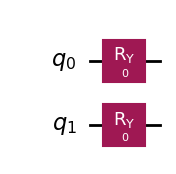

In [264]:
qc = encode(X[0])
qc.draw(output="mpl")

In [265]:
def ansatz(theta):
    qc = QuantumCircuit(2)

    qc.ry(theta[0], 0)
    qc.ry(theta[1], 1)
    qc.cx(0, 1)
    qc.ry(theta[2], 0)
    qc.ry(theta[3], 1)


    return qc

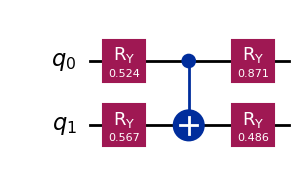

In [266]:
theta = np.random.rand(4)
qc = ansatz(theta)
qc.draw(output="mpl")

In [267]:
def build_circuit(x, theta):
    qc = QuantumCircuit(2)

    qc.compose(encode(x), inplace=True)
    qc.compose(ansatz(theta), inplace=True)

    return qc

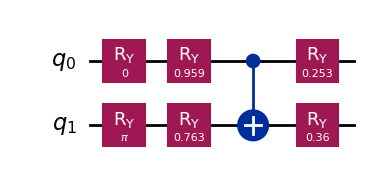

In [268]:
theta = np.random.rand(4)
qc = build_circuit(X[1], theta)
qc.draw(output="mpl")

In [269]:
from qiskit.quantum_info import Statevector

def forward(x, theta):
    qc = build_circuit(x, theta)

    state = Statevector.from_instruction(qc)

    # expectation of Z on qubit 0
    return float(np.real(state.expectation_value([[1, 0], [0, -1]], [0])))

In [270]:
theta0 = np.random.rand(4)

for x in X:
    print(forward(x, theta0))

0.6487424729946666
0.8958976319061006
-0.6487424729946668
-0.8958976319061003


In [271]:
def loss(theta, X, Y):
    preds = np.array([forward(x, theta) for x in X])
    return float(np.mean((preds - Y) ** 2))

In [272]:
theta0 = np.random.rand(4)
print(loss(theta0, X, Y))

1.2674127284100982


In [ ]:
theta0 = np.random.rand(4)

result = minimize(loss, theta0, args=(X, Y), method='COBYLA')

theta_opt = result.x

In [274]:
print("Initial theta:", theta0)
print("Optimized theta:", theta_opt)
print("Final loss:", result.fun)
print("Success:", result.success)
print("Message:", result.message)

Initial theta: [0.08162137 0.29237048 0.39289661 0.00813721]
Optimized theta: [ 1.57079279  1.57077431  1.57073336 -0.14967016]
Final loss: 5.025804174462482e-18
Success: True
Message: Return from COBYLA because the trust region radius reaches its lower bound.


In [275]:
for x, y_true in zip(X, Y):
    pred = forward(x, theta_opt)
    y_pred = 1 if pred >= 0 else -1
    print(f"x={x}, pred={pred:.4f}, true={y_true}, predicted={y_pred}")

x=[0 0], pred=-1.0000, true=-1, predicted=-1
x=[0 1], pred=1.0000, true=1, predicted=1
x=[1 0], pred=1.0000, true=1, predicted=1
x=[1 1], pred=-1.0000, true=-1, predicted=-1


In [276]:
pred_labels = np.array([1 if forward(x, theta_opt) >= 0 else -1 for x in X])
accuracy = np.mean(pred_labels == Y)

print("Predicted labels:", pred_labels)
print("True labels     :", Y)
print("Accuracy        :", accuracy)

Predicted labels: [-1  1  1 -1]
True labels     : [-1  1  1 -1]
Accuracy        : 1.0
